In [3]:
from collections import deque
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['G'],
    'F': ['G'],
    'G': []
}
def bfs(graph, start, goal):
    queue = deque([[start]])
    visited = []
    seen = {start}

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node in visited:
            continue
        visited.append(node)

        if node == goal:
            return path, visited

        for neighbor in graph.get(node, []):
            if neighbor not in seen:
                seen.add(neighbor)
                queue.append(path + [neighbor])

    return None, visited

path_bfs, visited_bfs = bfs(graph, 'A', 'G')
print('Path:', path_bfs)
print('Visited:', visited_bfs)
print('Jumlah node visited:', len(visited_bfs))
print('Panjang path (edge):', len(path_bfs)-1 if path_bfs else None)

Path: ['A', 'B', 'E', 'G']
Visited: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
Jumlah node visited: 7
Panjang path (edge): 3


In [4]:
def dfs(graph, start, goal):
    stack = [[start]]
    visited = []
    seen = {start}

    while stack:
        path = stack.pop()
        node = path[-1]

        if node in visited:
            continue
        visited.append(node)

        if node == goal:
            return path, visited

        for neighbor in graph.get(node, []):
            if neighbor not in seen:
                seen.add(neighbor)
                stack.append(path + [neighbor])

    return None, visited

path_dfs, visited_dfs = dfs(graph, 'A', 'G')
print('Path:', path_dfs)
print('Visited:', visited_dfs)
print('Jumlah node visited:', len(visited_dfs))

Path: ['A', 'C', 'F', 'G']
Visited: ['A', 'C', 'F', 'G']
Jumlah node visited: 4


In [5]:
import heapq

graph_cost = {
    'A': [('B', 2), ('C', 5)],
    'B': [('D', 4), ('E', 1)],
    'C': [('F', 2)],
    'D': [('G', 3)],
    'E': [('G', 5)],
    'F': [('G', 1)],
    'G': []
}

def ucs(graph, start, goal):
    priority_queue = [(0, 0, [start])]
    counter = 1
    visited = []
    best_cost = {start: 0}

    while priority_queue:
        cost, _, path = heapq.heappop(priority_queue)
        node = path[-1]

        if node in visited:
            continue
        visited.append(node)

        if node == goal:
            return path, cost, visited

        for neighbor, edge_cost in graph.get(node, []):
            new_cost = cost + edge_cost
            if new_cost < best_cost.get(neighbor, float('inf')):
                best_cost[neighbor] = new_cost
                heapq.heappush(
                    priority_queue,
                    (new_cost, counter, path + [neighbor])
                )
                counter += 1

    return None, None, visited

path_ucs, cost_ucs, visited_ucs = ucs(graph_cost, 'A', 'G')
print('Path:', path_ucs)
print('Total cost:', cost_ucs)
print('Visited:', visited_ucs)
print('Jumlah node visited:', len(visited_ucs))

Path: ['A', 'B', 'E', 'G']
Total cost: 8
Visited: ['A', 'B', 'E', 'C', 'D', 'F', 'G']
Jumlah node visited: 7


In [6]:
from collections import deque
import heapq
import time

def bfs(graph, start, goal):
    queue = deque([(start, [start])])
    visited = []
    seen = set()

    while queue:
        node, path = queue.popleft()

        if node in seen:
            continue

        seen.add(node)
        visited.append(node)

        if node == goal:
            return path, visited

        for neighbor in graph.get(node, []):
            if neighbor not in seen:
                queue.append((neighbor, path + [neighbor]))

    return None, visited

def dfs(graph, start, goal):
    stack = [(start, [start])]
    visited = []
    seen = set()

    while stack:
        node, path = stack.pop()

        if node in seen:
            continue

        seen.add(node)
        visited.append(node)

        if node == goal:
            return path, visited

        for neighbor in graph.get(node, []):
            if neighbor not in seen:
                stack.append((neighbor, path + [neighbor]))

    return None, visited

def ucs(graph, start, goal):
    priority_queue = [(0, [start])]
    best_cost = {start: 0}
    visited = []
    expanded = set()

    while priority_queue:
        cost, path = heapq.heappop(priority_queue)
        node = path[-1]

        if cost != best_cost.get(node):
            continue

        if node in expanded:
            continue

        expanded.add(node)
        visited.append(node)

        if node == goal:
            return path, cost, visited

        for neighbor, edge_cost in graph.get(node, []):
            new_cost = cost + edge_cost

            if new_cost < best_cost.get(neighbor, float("inf")):
                best_cost[neighbor] = new_cost
                heapq.heappush(
                    priority_queue,
                    (new_cost, path + [neighbor])
                )

    return None, float("inf"), visited

In [7]:
scenario1 = {
    'A': [('B',1), ('C',1)],
    'B': [('D',1), ('E',1)],
    'C': [('F',1)],
    'D': [('G',1)],
    'E': [('G',1)],
    'F': [('G',1)],
    'G': []
}

scenario2 = {
    'A': [('B',2), ('C',5)],
    'B': [('D',4), ('E',1)],
    'C': [('F',2)],
    'D': [('G',3)],
    'E': [('G',5)],
    'F': [('G',1)],
    'G': []
}

scenario3 = {
    'A': [('B',2), ('C',5), ('H',1)],
    'B': [('D',4), ('E',1)],
    'C': [('F',2)],
    'D': [('G',3)],
    'E': [('G',5)],
    'F': [('G',1)],
    'H': [('I',1)],
    'I': [('J',1)],
    'J': [('G',1)],
    'G': []
}

scenario4 = {
    'A': [('B',2), ('C',5), ('X',10)],
    'B': [('D',4), ('E',1)],
    'C': [('F',2)],
    'D': [('G',3)],
    'E': [('G',5)],
    'F': [('G',1)],
    'X': [('G',10)],
    'G': []
}

In [8]:
def weighted_to_unweighted(graph):
    return {
        node: [neighbor for neighbor, cost in neighbors]
        for node, neighbors in graph.items()
    }

In [9]:
def benchmark_time(function, repeats=3000):
    for _ in range(100):
        function()

    start_time = time.perf_counter_ns()

    for _ in range(repeats):
        function()

    end_time = time.perf_counter_ns()

    total_ns = end_time - start_time
    average_ms = (total_ns / repeats) / 1_000_000

    return average_ms

In [10]:
def run_experiment(scenario, scenario_number):
    graph_unweighted = weighted_to_unweighted(scenario)

    algorithms = {
        "BFS": lambda: bfs(graph_unweighted, 'A', 'G'),
        "DFS": lambda: dfs(graph_unweighted, 'A', 'G'),
        "UCS": lambda: ucs(scenario, 'A', 'G')
    }

    print(f"\n===== SKENARIO {scenario_number} =====")

    for name, function in algorithms.items():
        result = function()

        if name == "UCS":
            path, cost, visited = result
        else:
            path, visited = result
            cost = 0
            for i in range(len(path) - 1):
                current = path[i]
                next_node = path[i + 1]
                for neighbor, edge_cost in scenario[current]:
                    if neighbor == next_node:
                        cost += edge_cost
                        break

        avg_ms = benchmark_time(function, repeats=3000)
        path_length = len(path) - 1
        node_count = len(visited)

        print(f"\nAlgoritma : {name}")
        print(f"Path      : {' -> '.join(path)}")
        print(f"Panjang   : {path_length}")
        print(f"Cost      : {cost}")
        print(f"Nodes     : {node_count}")
        print(f"Waktu     : {avg_ms:.6f} ms")

run_experiment(scenario1, 1)
run_experiment(scenario2, 2)
run_experiment(scenario3, 3)
run_experiment(scenario4, 4)


===== SKENARIO 1 =====

Algoritma : BFS
Path      : A -> B -> D -> G
Panjang   : 3
Cost      : 3
Nodes     : 7
Waktu     : 0.006149 ms

Algoritma : DFS
Path      : A -> C -> F -> G
Panjang   : 3
Cost      : 3
Nodes     : 4
Waktu     : 0.002985 ms

Algoritma : UCS
Path      : A -> B -> D -> G
Panjang   : 3
Cost      : 3
Nodes     : 7
Waktu     : 0.012241 ms

===== SKENARIO 2 =====

Algoritma : BFS
Path      : A -> B -> D -> G
Panjang   : 3
Cost      : 9
Nodes     : 7
Waktu     : 0.006575 ms

Algoritma : DFS
Path      : A -> C -> F -> G
Panjang   : 3
Cost      : 8
Nodes     : 4
Waktu     : 0.002996 ms

Algoritma : UCS
Path      : A -> B -> E -> G
Panjang   : 3
Cost      : 8
Nodes     : 7
Waktu     : 0.013243 ms

===== SKENARIO 3 =====

Algoritma : BFS
Path      : A -> B -> D -> G
Panjang   : 3
Cost      : 9
Nodes     : 9
Waktu     : 0.017560 ms

Algoritma : DFS
Path      : A -> H -> I -> J -> G
Panjang   : 4
Cost      : 4
Nodes     : 5
Waktu     : 0.009704 ms

Algoritma : UCS
Path      

# Komparasi Komprehensif Antara BFS dan UCS
Bagian ini menjalankan simulasi perbandingan performa antara Breadth-First Search (BFS) dan Uniform Cost Search (UCS) pada berbagai skenario kondisi graf.

In [13]:
from collections import deque
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def bfs(graph, start, goal):
    queue = deque([[start]])
    visited, seen = [], {start}
    while queue:
        path = queue.popleft(); node = path[-1]
        if node in visited: continue
        visited.append(node)
        if node == goal: return path, visited
        for nxt in graph.get(node, []):
            if nxt not in seen:
                seen.add(nxt); queue.append(path + [nxt])
    return None, visited

def ucs(graph, start, goal):
    pq = [(0, 0, [start])]
    counter = 1; visited = []; best = {start: 0}
    while pq:
        cost, _, path = heapq.heappop(pq); node = path[-1]
        if node in visited: continue
        visited.append(node)
        if node == goal: return path, cost, visited
        for nxt, edge_cost in graph.get(node, []):
            new_cost = cost + edge_cost
            if new_cost < best.get(nxt, float('inf')):
                best[nxt] = new_cost
                heapq.heappush(pq, (new_cost, counter, path+[nxt]))
                counter += 1
    return None, None, visited

def to_unweighted(graph):
    return {u: [v for v, _ in edges] for u, edges in graph.items()}

scenario1 = {
 'Storage':[('Lobby',2),('Stairs',7)],
 'Lobby':[('Lift',3),('Lab',10)],
 'Stairs':[('Hall',2)], 'Hall':[('Lab',1)],
 'Lift':[('Lab',2)], 'Lab':[('Destination',2)], 'Destination':[]}
scenario2 = {k:list(v) for k,v in scenario1.items()}
scenario2['Stairs']=[('Hall',20)]
scenario3 = {k:list(v) for k,v in scenario1.items()}
scenario3['Lobby']=list(scenario3['Lobby'])+[('Destination',15)]
scenario4 = {k:list(v) for k,v in scenario1.items()}
scenario4.pop('Stairs')

scenarios = [scenario1, scenario2, scenario3, scenario4]

# Menjalankan evaluasi algoritma
for number, graph in enumerate(scenarios, 1):
    unweighted = to_unweighted(graph)
    bfs_path, bfs_visited = bfs(unweighted, 'Storage', 'Destination')
    ucs_path, ucs_cost, ucs_visited = ucs(graph, 'Storage', 'Destination')
    bfs_cost = sum(next(w for v,w in graph[u] if v==v2) for u,v2 in zip(bfs_path,bfs_path[1:]))
    print(f"{number} BFS: {bfs_path} length={len(bfs_path)-1} cost={bfs_cost}")
    print(f"{number} UCS: {ucs_path} length={len(ucs_path)-1} cost={ucs_cost}")


1 BFS: ['Storage', 'Lobby', 'Lab', 'Destination'] length=3 cost=14
1 UCS: ['Storage', 'Lobby', 'Lift', 'Lab', 'Destination'] length=4 cost=9
2 BFS: ['Storage', 'Lobby', 'Lab', 'Destination'] length=3 cost=14
2 UCS: ['Storage', 'Lobby', 'Lift', 'Lab', 'Destination'] length=4 cost=9
3 BFS: ['Storage', 'Lobby', 'Destination'] length=2 cost=17
3 UCS: ['Storage', 'Lobby', 'Lift', 'Lab', 'Destination'] length=4 cost=9
4 BFS: ['Storage', 'Lobby', 'Lab', 'Destination'] length=3 cost=14
4 UCS: ['Storage', 'Lobby', 'Lift', 'Lab', 'Destination'] length=4 cost=9


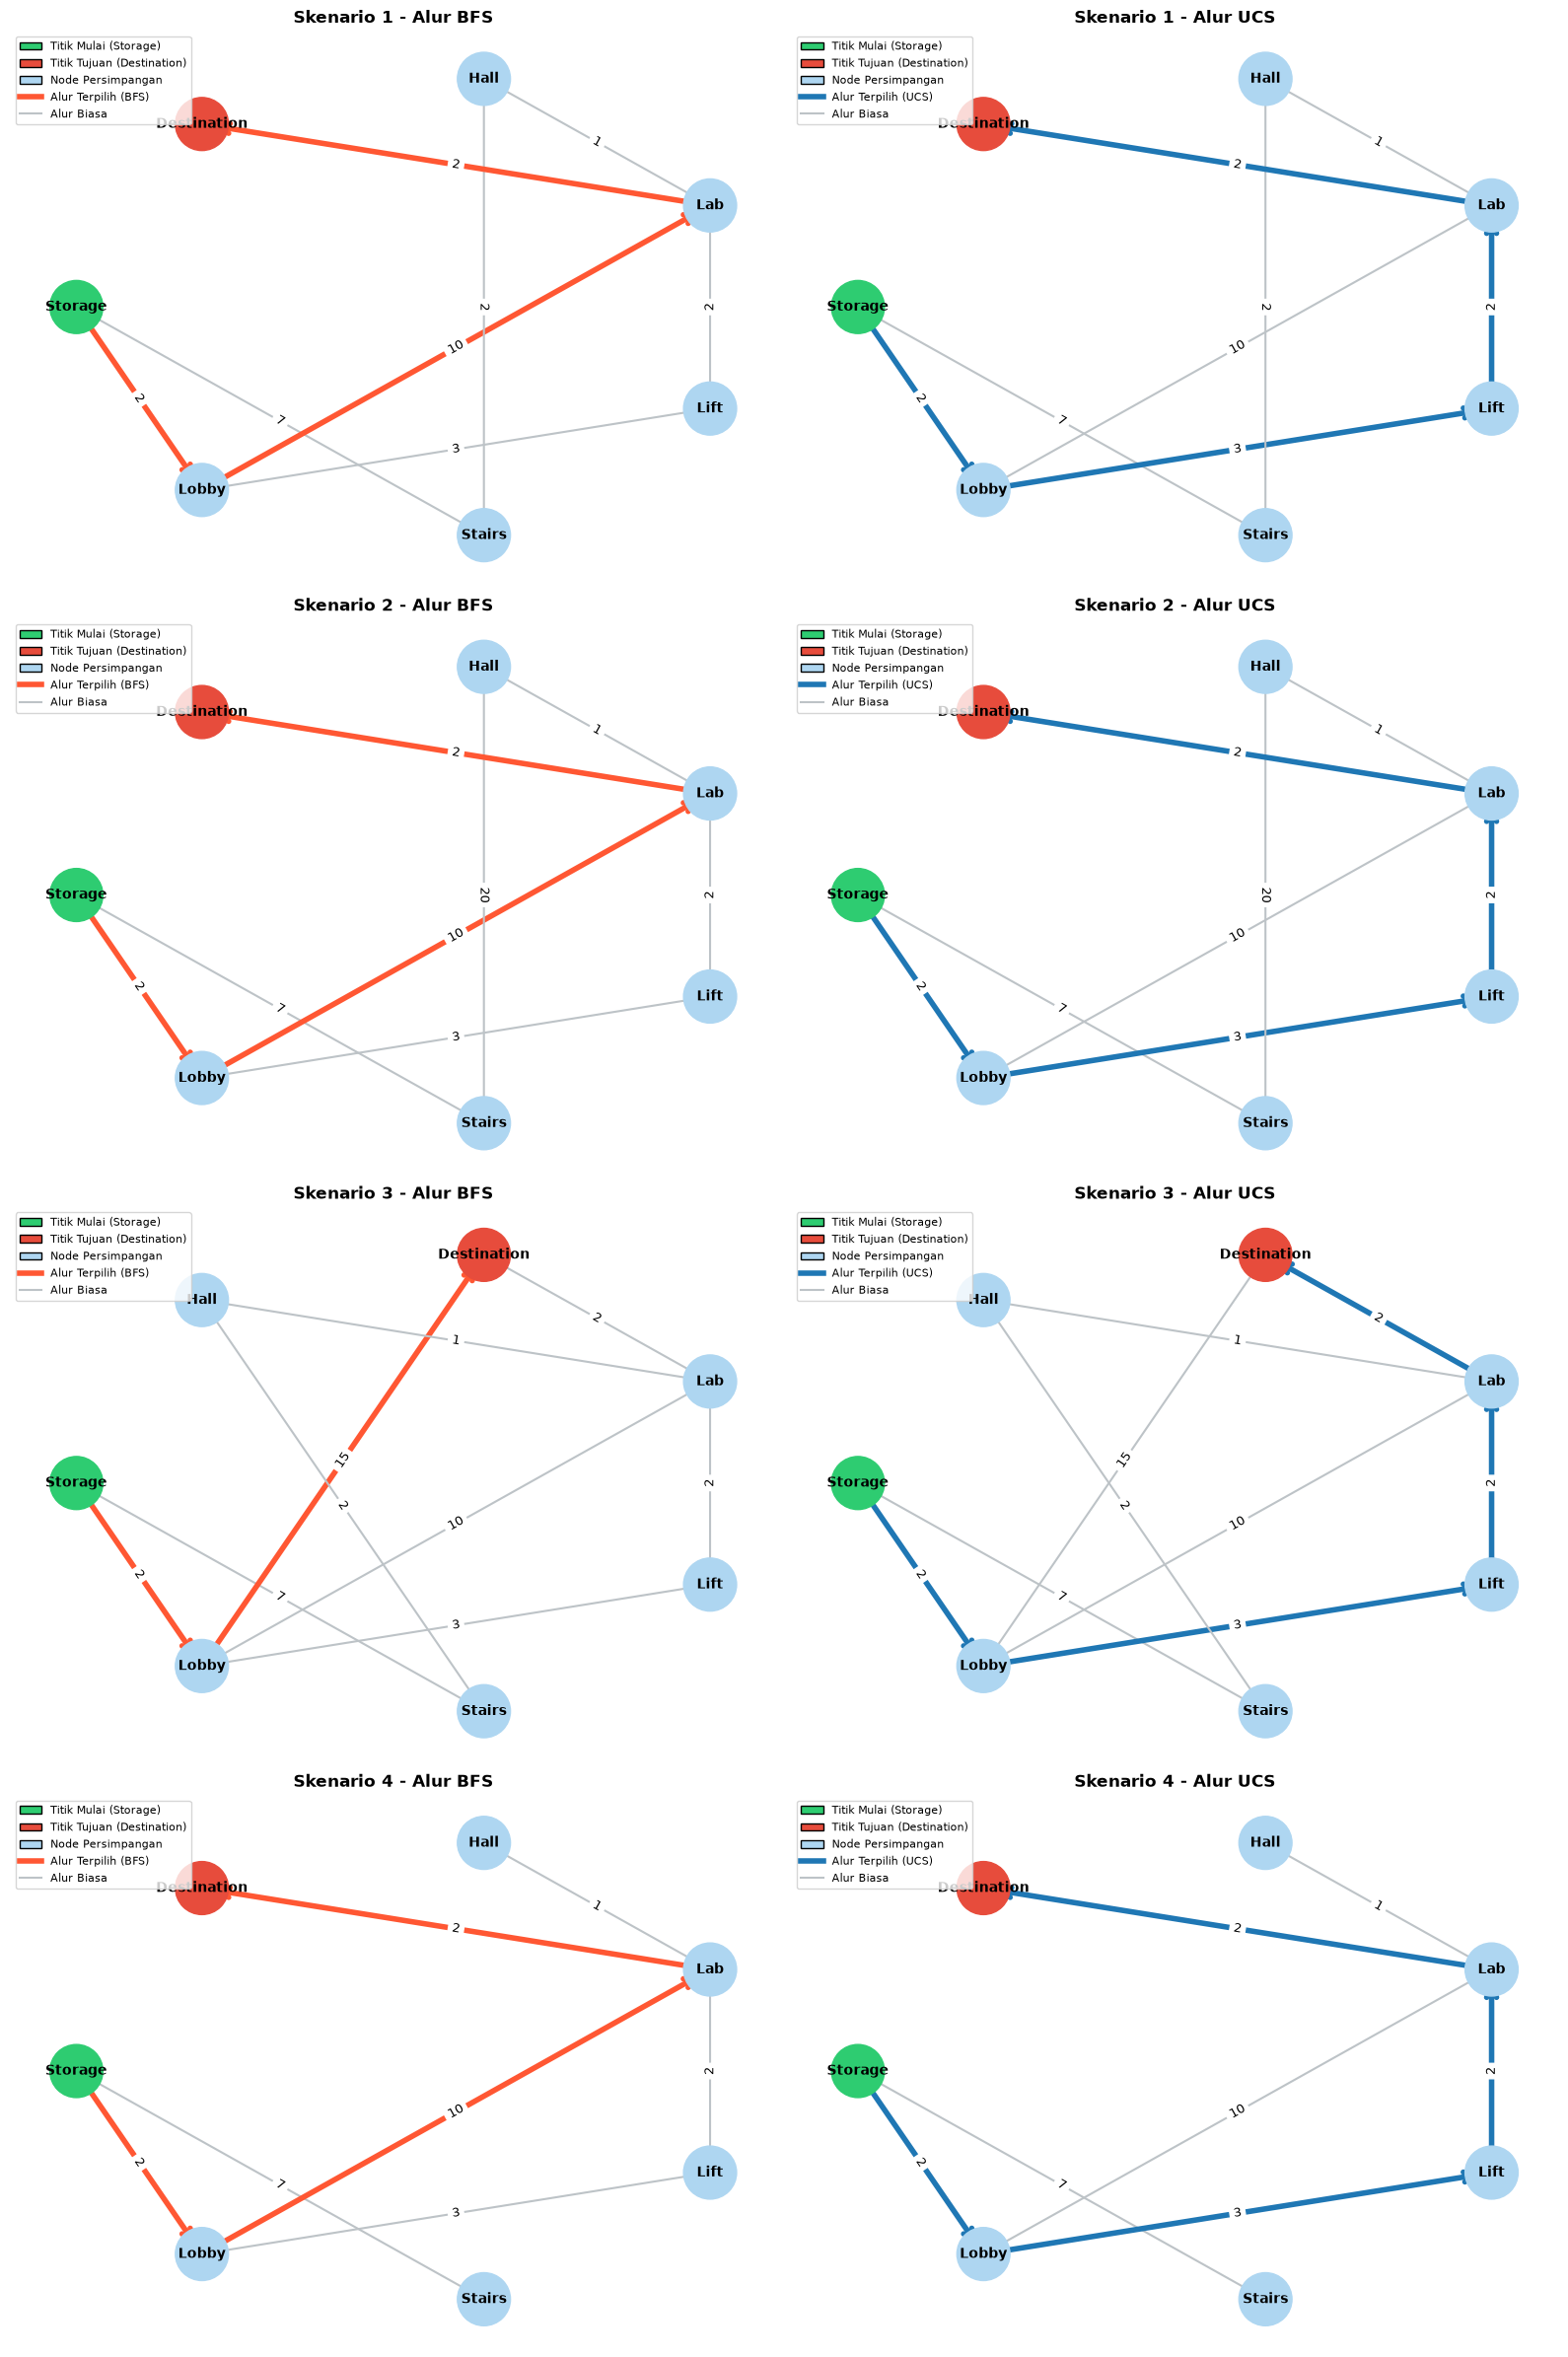

In [14]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Mempersiapkan visualisasi dengan pewarnaan alur yang informatif dan legenda
fig, axes = plt.subplots(4, 2, figsize=(16, 24))

for idx, graph in enumerate(scenarios):
    unweighted = to_unweighted(graph)
    bfs_path, _ = bfs(unweighted, 'Storage', 'Destination')
    ucs_path, _, _ = ucs(graph, 'Storage', 'Destination')

    # Membuat pasangan edge untuk mewarnai path
    bfs_edges = list(zip(bfs_path, bfs_path[1:])) if bfs_path else []
    ucs_edges = list(zip(ucs_path, ucs_path[1:])) if ucs_path else []

    # Menampilkan 2 kolom per skenario (Kolom kiri: BFS, Kolom kanan: UCS)
    for col_idx, (algo_name, path_edges, path_color) in enumerate([
        ("BFS", bfs_edges, "#FF5733"),  # Oranye/Merah untuk BFS
        ("UCS", ucs_edges, "#1F77B4")   # Biru untuk UCS
    ]):
        ax = axes[idx, col_idx]
        G = nx.DiGraph()
        for u, edges in graph.items():
            G.add_node(u)
            for v, w in edges:
                G.add_edge(u, v, weight=w)

        # Menentukan posisi layout yang konsisten
        pos = nx.shell_layout(G)

        # Menentukan warna node secara informatif
        node_colors = []
        for node in G.nodes():
            if node == 'Storage':
                node_colors.append('#2ECC71') # Hijau untuk Start
            elif node == 'Destination':
                node_colors.append('#E74C3C') # Merah untuk Goal
            else:
                node_colors.append('#AED6F1') # Biru muda untuk node biasa

        # Mengatur warna dan ketebalan garis edge
        edge_colors = []
        edge_widths = []
        for u, v in G.edges():
            if (u, v) in path_edges:
                edge_colors.append(path_color)
                edge_widths.append(4.0)
            else:
                edge_colors.append('#BDC3C7')
                edge_widths.append(1.5)

        # Menggambar Graf
        nx.draw_networkx_nodes(G, pos, node_size=1500, node_color=node_colors, ax=ax)
        nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
        nx.draw_networkx_edges(G, pos, edgelist=G.edges(), edge_color=edge_colors,
                               width=edge_widths, arrowstyle='->', arrowsize=18, ax=ax)

        # Menggambar Label Bobot
        labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=9, ax=ax)

        ax.set_title(f"Skenario {idx+1} - Alur {algo_name}", fontsize=12, fontweight='bold')
        ax.axis('off')

        # Membuat elemen legenda khusus untuk setiap subplot
        legend_elements = [
            Patch(facecolor='#2ECC71', edgecolor='black', label='Titik Mulai (Storage)'),
            Patch(facecolor='#E74C3C', edgecolor='black', label='Titik Tujuan (Destination)'),
            Patch(facecolor='#AED6F1', edgecolor='black', label='Node Persimpangan'),
            Line2D([0], [0], color=path_color, lw=4, label=f'Alur Terpilih ({algo_name})'),
            Line2D([0], [0], color='#BDC3C7', lw=1.5, label='Alur Biasa')
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=8, frameon=True)

plt.tight_layout()
plt.show()

In [15]:
cost_differences = []

for idx, graph in enumerate(scenarios, 1):
    unweighted = to_unweighted(graph)
    bfs_path, _ = bfs(unweighted, 'Storage', 'Destination')
    _, ucs_cost, _ = ucs(graph, 'Storage', 'Destination')

    # Menghitung cost untuk rute BFS
    bfs_cost = sum(next(w for v, w in graph[u] if v == v2) for u, v2 in zip(bfs_path, bfs_path[1:]))

    diff = bfs_cost - ucs_cost
    cost_differences.append(diff)
    print(f"Skenario {idx}: Cost BFS = {bfs_cost}, Cost UCS = {ucs_cost} | Selisih = {diff}")

average_diff = sum(cost_differences) / len(cost_differences)
print(f"\nRata-rata perbedaan biaya (BFS Cost - UCS Cost) di seluruh skenario: {average_diff:.2f}")

Skenario 1: Cost BFS = 14, Cost UCS = 9 | Selisih = 5
Skenario 2: Cost BFS = 14, Cost UCS = 9 | Selisih = 5
Skenario 3: Cost BFS = 17, Cost UCS = 9 | Selisih = 8
Skenario 4: Cost BFS = 14, Cost UCS = 9 | Selisih = 5

Rata-rata perbedaan biaya (BFS Cost - UCS Cost) di seluruh skenario: 5.75
